In [1]:
"""
Roof Texture Classification - Dual Training Mode
Clean implementation with two training modes:
1. With Augmentation (Conservative approach with class balancing)
2. Without Augmentation (Limited samples per class, no data duplication)
"""

import os
import pickle
import warnings
import sys
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from multiprocessing import cpu_count
from sklearn.metrics import f1_score
import numpy as np

# Warning suppression
os.environ['OPENCV_LOG_LEVEL'] = 'SILENT'
os.environ['OPENCV_OPENCL_DEVICE'] = 'disabled'
os.environ['PYTHONWARNINGS'] = 'ignore'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['OPENCV_IO_ENABLE_OPENEXR'] = '0'
os.environ['OPENCV_IO_ENABLE_JASPER'] = '0'

# Save original stderr file descriptor
original_stderr_fd = os.dup(2)

def silence_stderr():
    """Redirect stderr to null at the file descriptor level"""
    null_fd = os.open(os.devnull, os.O_WRONLY)
    os.dup2(null_fd, 2)
    os.close(null_fd)

def restore_stderr():
    """Restore original stderr"""
    os.dup2(original_stderr_fd, 2)

# Apply warning suppression
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
for category in [UserWarning, DeprecationWarning, RuntimeWarning, FutureWarning, Warning]:
    warnings.filterwarnings("ignore", category=category)

# Specific libpng warning patterns
libpng_patterns = [".*iCCP.*", ".*libpng.*", ".*sRGB.*", ".*profile.*", ".*PNG.*", ".*color.*"]
for pattern in libpng_patterns:
    warnings.filterwarnings("ignore", message=pattern)

# Logging suppression
import logging
logging.disable(logging.CRITICAL)
for logger_name in ['PIL', 'PIL.PngImagePlugin', 'PIL.Image', 'matplotlib', 'cv2']:
    logging.getLogger(logger_name).setLevel(logging.CRITICAL)
    logging.getLogger(logger_name).disabled = True

# Context manager for warning suppression
import contextlib

@contextlib.contextmanager
def nuclear_silence():
    """Ultimate silence - redirects stderr at file descriptor level"""
    silence_stderr()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            yield
        finally:
            restore_stderr()

# Import libraries with suppression
with nuclear_silence():
    import PIL.Image
    PIL.Image.warnings.simplefilter('ignore')
    from PIL import Image
    import cv2
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader as TorchDataLoader, Dataset
    from torchvision import models, transforms
    import matplotlib.pyplot as plt
    from tqdm import tqdm
    from sklearn.model_selection import train_test_split
    from sklearn.utils.class_weight import compute_class_weight

# Additional suppression for OpenCV warnings
os.environ['OPENCV_LOG_LEVEL'] = 'ERROR'


In [2]:
class AugmentationConfig:
    """Configuration for training WITH augmentation"""
    BASE_PATH = "/home/student/sky-scan/data"
    BATCH_SIZE = 16
    NUM_EPOCHS = 150
    LEARNING_RATE = 0.0005
    IMAGE_SIZE = 224
    NUM_WORKERS = 2
    PATIENCE = 8
    MIN_CONTOUR_AREA = 100
    MODEL_SAVE_PATH = "models/augmentation_roof_texture_model.pth"

class NoAugmentationConfig:
    """Configuration for training WITHOUT augmentation"""
    BASE_PATH = "/home/student/sky-scan/data"
    BATCH_SIZE = 16
    NUM_EPOCHS = 100
    LEARNING_RATE = 0.001
    IMAGE_SIZE = 224
    NUM_WORKERS = 2
    PATIENCE = 10
    MIN_CONTOUR_AREA = 100
    MAX_SAMPLES_PER_CLASS = 5000
    MODEL_SAVE_PATH = "models/no_augmentation_roof_texture_model.pth"


In [3]:
def set_seed(seed=42):
    """Set random seeds for reproducibility"""
    torch.manual_seed(seed)
    np.random.seed(seed)

def get_device():
    """Get available device"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True
        print(f"Using GPU: {torch.cuda.get_device_name()}")
    return device


In [4]:
class RoofDataLoader:
    """Handles data loading and preprocessing"""

    def __init__(self, base_path):
        self.original_dir = f"{base_path}/patch"
        self.binary_dir = f"{base_path}/patch-binary"
        self.color_dir = f"{base_path}/patch-texture"
        self.cache_dir = f"{base_path}/cache"
        os.makedirs(self.cache_dir, exist_ok=True)

    def load_file_paths(self):
        """Load file paths with caching"""
        cache_file = os.path.join(self.cache_dir, 'file_paths.pkl')

        if os.path.exists(cache_file):
            print("Loading paths from cache...")
            with open(cache_file, 'rb') as f:
                return pickle.load(f)

        print("Scanning directories...")
        filenames = sorted(os.listdir(self.original_dir))

        def check_files(filename):
            paths = [
                os.path.join(self.original_dir, filename),
                os.path.join(self.binary_dir, filename),
                os.path.join(self.color_dir, filename)
            ]
            return paths if all(os.path.exists(p) for p in paths) else None

        with ThreadPoolExecutor(max_workers=cpu_count()) as executor:
            results = list(tqdm(
                executor.map(check_files, filenames),
                total=len(filenames),
                desc="Checking files"
            ))

        valid_paths = [r for r in results if r is not None]
        paths = list(zip(*valid_paths)) if valid_paths else ([], [], [])

        with open(cache_file, 'wb') as f:
            pickle.dump(paths, f)

        return paths


In [5]:
def get_label_from_color(color_patch, tolerance=15):
    """Extract label from color-coded patch"""
    colors = {
        "smooth": np.array([83, 217, 56]),
        "average": np.array([252, 240, 3]),
        "rough": np.array([255, 0, 0])
    }

    pixels = color_patch.reshape(-1, 3)
    counts = {}

    for label, color in colors.items():
        distances = np.abs(pixels - color).max(axis=1)
        counts[label] = np.sum(distances <= tolerance)

    return max(counts, key=counts.get) if max(counts.values()) > 50 else None


In [6]:
def process_image(args):
    """Process a single image to extract patches and labels"""
    img_path, binary_path, color_path, min_area, target_size = args

    try:
        # Load images with warning suppression
        with nuclear_silence():
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

            binary = cv2.imread(binary_path, cv2.IMREAD_GRAYSCALE)
            color = cv2.imread(color_path)
            color = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)

        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

        patches = []
        labels = []

        if valid_contours:
            for contour in valid_contours:
                x, y, w, h = cv2.boundingRect(contour)

                # Add padding
                padding = 10
                x = max(0, x - padding)
                y = max(0, y - padding)
                w = min(img.shape[1] - x, w + 2 * padding)
                h = min(img.shape[0] - y, h + 2 * padding)

                if w < 20 or h < 20:
                    continue

                # Extract and resize patches
                img_patch = cv2.resize(img[y:y+h, x:x+w], target_size)
                color_patch = cv2.resize(color[y:y+h, x:x+w], target_size)

                label = get_label_from_color(color_patch)

                if label is None:
                    continue

                patches.append(img_patch)
                labels.append(label)
        else:
            # Use full image if no contours
            img_patch = cv2.resize(img, target_size)
            color_patch = cv2.resize(color, target_size)
            label = get_label_from_color(color_patch)

            if label is not None:
                patches.append(img_patch)
                labels.append(label)

        return patches, labels

    except Exception as e:
        print(f"Error processing image: {e}")
        return [], []


In [7]:
def extract_patches(image_paths, binary_paths, color_paths, config):
    """Extract patches from all images"""
    cache_file = os.path.join(config.BASE_PATH, 'cache', 'patches_no_contour_removed.pkl')

    if os.path.exists(cache_file):
        print("Loading patches from cache...")
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    print("Extracting patches...")
    args_list = [
        (image_paths[i], binary_paths[i], color_paths[i],
         config.MIN_CONTOUR_AREA, (config.IMAGE_SIZE, config.IMAGE_SIZE))
        for i in range(len(image_paths))
    ]

    all_patches = []
    all_labels = []

    with ThreadPoolExecutor(max_workers=cpu_count()) as executor:
        results = list(tqdb(
            executor.map(process_image, args_list),
            total=len(args_list),
            desc="Processing images"
        ))

    for patches, labels in results:
        all_patches.extend(patches)
        all_labels.extend(labels)

    # Filter out any remaining None or "no_contour" labels
    filtered_patches = []
    filtered_labels = []
    for patch, label in zip(all_patches, all_labels):
        if label is not None and label != "no_contour":
            filtered_patches.append(patch)
            filtered_labels.append(label)

    patches_array = np.array(filtered_patches) if filtered_patches else np.array([])

    with open(cache_file, 'wb') as f:
        pickle.dump((patches_array, filtered_labels), f)

    return patches_array, filtered_labels


In [8]:
def balance_dataset(patches, labels, strategy='hybrid'):
    """Balance dataset using hybrid strategy and track augmented samples"""
    print(f"\n=== DATASET BALANCING ({strategy.upper()}) ===")

    # Count original distribution
    label_counts = Counter(labels)
    print("Original distribution:")
    for label, count in sorted(label_counts.items()):
        print(f"  {label}: {count} samples ({count/len(labels)*100:.1f}%)")

    # Hybrid balancing approach
    median_count = int(np.median(list(label_counts.values())))
    target_count = median_count * 2

    print(f"\nHybrid balancing to ~{target_count} samples per class...")

    balanced_patches = []
    balanced_labels = []
    augmented_patches = []  # Track augmented samples
    augmented_labels = []   # Track augmented labels
    augmented_info = []     # Track which samples are augmented

    # Group by labels
    label_to_data = {}
    for idx, label in enumerate(labels):
        if label not in label_to_data:
            label_to_data[label] = []
        label_to_data[label].append(patches[idx])

    # Balance each class
    for label, class_patches in label_to_data.items():
        current_count = len(class_patches)

        if current_count > target_count:
            # Undersample
            np.random.seed(42)
            selected_indices = np.random.choice(current_count, target_count, replace=False)
            for idx in selected_indices:
                balanced_patches.append(class_patches[idx])
                balanced_labels.append(label)
        elif current_count < target_count:
            # Keep original samples
            for patch in class_patches:
                balanced_patches.append(patch)
                balanced_labels.append(label)

            # Oversample (these are the augmented samples)
            needed = target_count - current_count
            np.random.seed(42)
            oversample_indices = np.random.choice(current_count, needed, replace=True)

            print(f"  Creating {needed} augmented samples for class '{label}'")

            for idx in oversample_indices:
                # Add to balanced dataset
                balanced_patches.append(class_patches[idx])
                balanced_labels.append(label)

                # Track as augmented
                augmented_patches.append(class_patches[idx])
                augmented_labels.append(label)
                augmented_info.append({
                    'class': label,
                    'original_idx': idx,
                    'augmented_idx': len(balanced_patches) - 1
                })
        else:
            # Keep as is
            for patch in class_patches:
                balanced_patches.append(patch)
                balanced_labels.append(label)

    balanced_patches = np.array(balanced_patches)
    augmented_patches = np.array(augmented_patches) if augmented_patches else np.array([])

    # Print final distribution
    final_counts = Counter(balanced_labels)
    print("\nFinal distribution:")
    for label, count in sorted(final_counts.items()):
        print(f"  {label}: {count} samples ({count/len(balanced_labels)*100:.1f}%)")

    print(f"\nTotal augmented samples created: {len(augmented_patches)}")

    # Store augmented data globally for access
    global _augmented_data
    _augmented_data = {
        'patches': augmented_patches,
        'labels': augmented_labels,
        'info': augmented_info
    }

    return balanced_patches, balanced_labels


In [9]:
def limit_samples_per_class(patches, labels, max_samples_per_class=5000):
    """Limit the number of samples per class to a maximum value"""
    print(f"\n=== LIMITING SAMPLES PER CLASS (MAX: {max_samples_per_class}) ===")

    # Count original distribution
    original_counts = Counter(labels)
    print("Original distribution:")
    for label, count in sorted(original_counts.items()):
        print(f"  {label}: {count} samples")

    # Group samples by class
    class_to_indices = defaultdict(list)
    for idx, label in enumerate(labels):
        class_to_indices[label].append(idx)

    # Limit samples per class
    limited_indices = []
    class_stats = {}

    for label, indices in class_to_indices.items():
        original_count = len(indices)

        if original_count > max_samples_per_class:
            # Take only first max_samples_per_class samples
            selected_indices = indices[:max_samples_per_class]
            limited_count = max_samples_per_class
            print(f"  {label}: Limited from {original_count} to {limited_count} samples (removed {original_count - limited_count})")
        else:
            # Keep all samples
            selected_indices = indices
            limited_count = original_count
            print(f"  {label}: Kept all {limited_count} samples")

        limited_indices.extend(selected_indices)
        class_stats[label] = {
            'original_count': original_count,
            'limited_count': limited_count,
            'removed_count': original_count - limited_count
        }

    # Extract limited patches and labels
    limited_patches = patches[limited_indices]
    limited_labels = [labels[idx] for idx in limited_indices]

    # Print final distribution
    final_counts = Counter(limited_labels)
    print("\nFinal distribution after limiting:")
    total_removed = 0
    for label, count in sorted(final_counts.items()):
        removed = class_stats[label]['removed_count']
        total_removed += removed
        print(f"  {label}: {count} samples (removed {removed})")

    print(f"\nTotal samples removed: {total_removed}")
    print(f"Total samples remaining: {len(limited_labels)}")

    return limited_patches, limited_labels, class_stats


In [10]:
def get_transforms(image_size, use_augmentation=True):
    """Get data transforms based on augmentation mode"""

    if use_augmentation:
        # Aggressive data transforms with strong augmentation
        train_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), shear=10),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0, inplace=False)
        ])
    else:
        # No augmentation for training
        train_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    val_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform


In [11]:
class RoofDataset(Dataset):
    """PyTorch dataset for roof patches"""

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

        # Create label mapping
        unique_labels = sorted(list(set(labels)))
        self.label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
        self.idx_to_label = {idx: label for label, idx in self.label_to_idx.items()}

        # Convert labels to indices
        self.label_indices = [self.label_to_idx[label] for label in labels]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        if image.dtype != np.uint8:
            image = (image * 255).astype(np.uint8)

        if self.transform:
            with nuclear_silence():
                image = self.transform(image)

        return image, self.label_indices[idx]


In [12]:
class RoofClassifier(nn.Module):
    """CNN model with frozen backbone and simple head"""

    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # Keep the backbone frozen for Stage 1
        for param in self.backbone.parameters():
            param.requires_grad = False

        num_features = self.backbone.classifier[1].in_features

        # Simplified classifier head
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


In [13]:
class Trainer:
    """Trainer with F1 score tracking and enhanced early stopping"""

    def __init__(self, model, device, config):
        self.model = model
        self.device = device
        self.config = config

    def train_epoch(self, train_loader, optimizer, criterion):
        """Training epoch with F1 score tracking and gradient clipping"""
        self.model.train()
        total_loss = 0
        all_predictions = []
        all_targets = []

        for inputs, targets in tqdm(train_loader, desc="Training"):
            with nuclear_silence():
                inputs, targets = inputs.to(self.device), targets.to(self.device)

            optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            # Gentle gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=2.0)

            optimizer.step()
            total_loss += loss.item()

            # Collect predictions and targets for F1 calculation
            _, predicted = outputs.max(1)
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

        # Calculate F1 score for the epoch
        train_f1 = f1_score(all_targets, all_predictions, average='weighted', zero_division=0)
        return total_loss / len(train_loader), train_f1

    def validate(self, val_loader, criterion):
        """Validation with F1 score tracking"""
        self.model.eval()
        total_loss = 0
        all_predictions = []
        all_targets = []

        with torch.no_grad():
            for inputs, targets in val_loader:
                with nuclear_silence():
                    inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.model(inputs)
                loss = criterion(outputs, targets)

                total_loss += loss.item()

                # Collect predictions and targets for F1 calculation
                _, predicted = outputs.max(1)
                all_predictions.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())

        # Calculate F1 score for validation
        val_f1 = f1_score(all_targets, all_predictions, average='weighted', zero_division=0)
        return total_loss / len(val_loader), val_f1

    def train(self, train_loader, val_loader, class_weights):
        """Training loop with F1 score tracking and overfitting early stopping"""

        # Light label smoothing
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

        # AdamW with light weight decay
        optimizer = optim.AdamW(
            self.model.parameters(),
            lr=self.config.LEARNING_RATE,
            weight_decay=0.005
        )

        # Learning rate scheduler
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            patience=5,
            factor=0.7,
            verbose=True
        )

        best_val_f1 = 0
        patience_counter = 0
        overfitting_patience_counter = 0  # New counter for overfitting detection
        overfitting_patience = 5  # Patience for overfitting early stopping
        overfitting_threshold = 0.10  # 10% difference threshold

        train_losses, val_losses = [], []
        train_f1s, val_f1s = [], []

        for epoch in range(self.config.NUM_EPOCHS):
            train_loss, train_f1 = self.train_epoch(train_loader, optimizer, criterion)
            val_loss, val_f1 = self.validate(val_loader, criterion)

            scheduler.step(val_loss)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_f1s.append(train_f1)
            val_f1s.append(val_f1)

            # Calculate overfitting percentage
            if train_loss > 0:  # Avoid division by zero
                loss_difference_pct = (val_loss - train_loss) / train_loss
            else:
                loss_difference_pct = 0

            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{self.config.NUM_EPOCHS}: "
                  f"Train Loss: {train_loss:.4f}, F1: {train_f1:.4f} | "
                  f"Val Loss: {val_loss:.4f}, F1: {val_f1:.4f} | "
                  f"Loss Diff: {loss_difference_pct*100:.1f}% | LR: {current_lr:.6f}")

            # Check for overfitting (val_loss > train_loss by more than 10%)
            if loss_difference_pct > overfitting_threshold:
                overfitting_patience_counter += 1
                print(f"⚠️  Overfitting detected! Val loss {loss_difference_pct*100:.1f}% higher than train loss "
                      f"(patience: {overfitting_patience_counter}/{overfitting_patience})")
            else:
                overfitting_patience_counter = 0  # Reset counter if not overfitting

            # Save best model based on F1 score
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                patience_counter = 0
                self.save_model()
                print(f"New best model saved! Val F1: {val_f1:.4f}")
            else:
                patience_counter += 1

            # Early stopping conditions
            if patience_counter >= self.config.PATIENCE:
                print(f"Early stopping due to no improvement in validation F1 for {self.config.PATIENCE} epochs!")
                break

            if overfitting_patience_counter >= overfitting_patience:
                print(f"🛑 Early stopping due to overfitting! Val loss consistently {overfitting_threshold*100}% "
                      f"higher than train loss for {overfitting_patience} epochs.")
                break

        return {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_f1s': train_f1s,
            'val_f1s': val_f1s,
            'best_val_f1': best_val_f1
        }

    def save_model(self):
        """Save model checkpoint"""
        os.makedirs(os.path.dirname(self.config.MODEL_SAVE_PATH), exist_ok=True)
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'model_class': type(self.model).__name__
        }, self.config.MODEL_SAVE_PATH)


In [14]:
def plot_training_history(history, title_suffix=""):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history['train_losses'], label='Train Loss')
    ax1.plot(history['val_losses'], label='Val Loss')
    ax1.set_title(f'Training Loss {title_suffix}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['train_f1s'], label='Train F1 Score')
    ax2.plot(history['val_f1s'], label='Val F1 Score')
    ax2.set_title(f'Training F1 Score {title_suffix}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1 Score')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


In [15]:
def train_with_augmentation():
    """Train model WITH augmentation and class balancing"""
    print("=== TRAINING WITH AUGMENTATION ===")

    config = AugmentationConfig()
    set_seed(42)
    device = get_device()

    # Load data
    data_loader = RoofDataLoader(config.BASE_PATH)
    image_paths, binary_paths, color_paths = data_loader.load_file_paths()
    print(f"Found {len(image_paths)} image sets")

    # Extract patches
    patches, labels = extract_patches(image_paths, binary_paths, color_paths, config)
    print(f"Extracted {len(patches)} patches")

    # Show original distribution
    label_counts = Counter(labels)
    print("Original label distribution:", label_counts)

    # Apply class balancing - use hybrid strategy
    patches, labels = balance_dataset(patches, labels, strategy='hybrid')

    # Create transforms with augmentation
    train_transform, val_transform = get_transforms(config.IMAGE_SIZE, use_augmentation=True)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        patches, labels, test_size=0.2, random_state=42, stratify=labels
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )

    print(f"Dataset split - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

    # Create datasets
    train_dataset = RoofDataset(X_train, y_train, train_transform)
    val_dataset = RoofDataset(X_val, y_val, val_transform)
    test_dataset = RoofDataset(X_test, y_test, val_transform)

    # Create data loaders
    train_loader = TorchDataLoader(
        train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=config.NUM_WORKERS
    )
    val_loader = TorchDataLoader(
        val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS
    )
    test_loader = TorchDataLoader(
        test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS
    )

    # Create model
    num_classes = len(train_dataset.label_to_idx)
    print(f"Number of classes: {num_classes}")
    model = RoofClassifier(num_classes).to(device)

    # Calculate class weights
    unique_labels = list(train_dataset.label_to_idx.keys())
    y_indices = [train_dataset.label_to_idx[label] for label in y_train]
    class_weights = compute_class_weight('balanced', classes=np.unique(y_indices), y=y_indices)
    class_weights = torch.FloatTensor(class_weights).to(device)

    print(f"Class weights: {class_weights}")

    # Train model
    trainer = Trainer(model, device, config)
    print("Starting training with augmentation...")
    history = trainer.train(train_loader, val_loader, class_weights)

    # Plot results
    plot_training_history(history, "(With Augmentation)")

    # Test evaluation
    print("Evaluating on test set...")
    try:
        model.load_state_dict(torch.load(config.MODEL_SAVE_PATH)['model_state_dict'])
        test_loss, test_f1 = trainer.validate(test_loader, nn.CrossEntropyLoss())
        print(f"Final Test F1 Score: {test_f1:.4f}")
    except FileNotFoundError:
        print("Model file not found, using current model for test evaluation")
        test_loss, test_f1 = trainer.validate(test_loader, nn.CrossEntropyLoss())
        print(f"Final Test F1 Score: {test_f1:.4f}")

    return model, history, trainer


In [16]:
def train_without_augmentation():
    """Train model WITHOUT augmentation, limiting samples per class"""
    print("=== TRAINING WITHOUT AUGMENTATION ===")

    config = NoAugmentationConfig()
    set_seed(42)
    device = get_device()

    # Load data
    data_loader = RoofDataLoader(config.BASE_PATH)
    image_paths, binary_paths, color_paths = data_loader.load_file_paths()
    print(f"Found {len(image_paths)} image sets")

    # Extract patches
    patches, labels = extract_patches(image_paths, binary_paths, color_paths, config)
    print(f"Extracted {len(patches)} patches before limiting")

    # Show original distribution
    original_counts = Counter(labels)
    print("Original class distribution:")
    for label, count in sorted(original_counts.items()):
        print(f"  {label}: {count} samples")

    # Limit samples per class (NO AUGMENTATION)
    limited_patches, limited_labels, class_stats = limit_samples_per_class(
        patches, labels, config.MAX_SAMPLES_PER_CLASS
    )

    # Create transforms without augmentation
    train_transform, val_transform = get_transforms(config.IMAGE_SIZE, use_augmentation=False)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        limited_patches, limited_labels, test_size=0.2, random_state=42, stratify=limited_labels
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )

    print(f"\nDataset split - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

    # Create datasets
    train_dataset = RoofDataset(X_train, y_train, train_transform)
    val_dataset = RoofDataset(X_val, y_val, val_transform)
    test_dataset = RoofDataset(X_test, y_test, val_transform)

    # Print final train/val/test distribution
    print("\nFinal training set distribution:")
    train_counts = Counter(y_train)
    for label, count in sorted(train_counts.items()):
        print(f"  {label}: {count} samples")

    # Create data loaders
    train_loader = TorchDataLoader(
        train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=config.NUM_WORKERS
    )
    val_loader = TorchDataLoader(
        val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS
    )
    test_loader = TorchDataLoader(
        test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS
    )

    # Create model
    num_classes = len(train_dataset.label_to_idx)
    print(f"\nNumber of classes: {num_classes}")
    model = RoofClassifier(num_classes).to(device)

    # Calculate class weights for the limited dataset
    unique_labels = list(train_dataset.label_to_idx.keys())
    y_indices = [train_dataset.label_to_idx[label] for label in y_train]
    class_weights = compute_class_weight('balanced', classes=np.unique(y_indices), y=y_indices)
    class_weights = torch.FloatTensor(class_weights).to(device)

    print(f"Class weights: {class_weights}")

    # Train model
    trainer = Trainer(model, device, config)
    print("\nStarting training without augmentation...")
    history = trainer.train(train_loader, val_loader, class_weights)

    # Plot results
    plot_training_history(history, "(Without Augmentation)")

    # Test evaluation
    print("\nEvaluating on test set...")
    try:
        model.load_state_dict(torch.load(config.MODEL_SAVE_PATH)['model_state_dict'])
        test_loss, test_f1 = trainer.validate(test_loader, nn.CrossEntropyLoss())
        print(f"Final Test F1 Score: {test_f1:.4f}")
    except FileNotFoundError:
        print("Model file not found, using current model for test evaluation")
        test_loss, test_f1 = trainer.validate(test_loader, nn.CrossEntropyLoss())
        print(f"Final Test F1 Score: {test_f1:.4f}")

    return model, history, trainer, class_stats


In [17]:
def get_augmented_images():
    """Get only the augmented images that were created during class balancing"""
    global _augmented_data

    if '_augmented_data' not in globals() or not _augmented_data:
        print("No augmented data found. Make sure to run train_with_augmentation() first.")
        return np.array([]), []

    return _augmented_data['patches'], _augmented_data['labels']


In [18]:
def visualize_augmented_images(max_samples_per_class=5, figsize=(20, 12)):
    """Visualize augmented images alongside their ground truth originals"""
    global _augmented_data

    if '_augmented_data' not in globals() or not _augmented_data:
        print("No augmented data found. Make sure to run train_with_augmentation() first.")
        return

    augmented_patches = _augmented_data['patches']
    augmented_labels = _augmented_data['labels']
    augmented_info = _augmented_data['info']

    if len(augmented_patches) == 0:
        print("No augmented images to display.")
        return

    # Group by class
    class_data = {}
    for i, info in enumerate(augmented_info):
        class_name = info['class']
        if class_name not in class_data:
            class_data[class_name] = {'augmented': [], 'original': [], 'info': []}

        if len(class_data[class_name]['augmented']) < max_samples_per_class:
            class_data[class_name]['augmented'].append(augmented_patches[i])
            class_data[class_name]['original'].append(augmented_patches[i])  # This is the duplicate
            class_data[class_name]['info'].append(info)

    # Calculate subplot layout (2 columns per sample: original + augmented)
    num_classes = len(class_data)
    max_samples = max(len(data['augmented']) for data in class_data.values())
    cols_per_sample = 2  # original + augmented

    fig, axes = plt.subplots(num_classes, max_samples * cols_per_sample, figsize=figsize)

    # Ensure axes is 2D
    if num_classes == 1:
        axes = axes.reshape(1, -1)
    if max_samples * cols_per_sample == 1:
        axes = axes.reshape(-1, 1)

    # Plot images
    for class_idx, (class_name, data) in enumerate(class_data.items()):
        for sample_idx, (aug_patch, orig_patch, info) in enumerate(zip(data['augmented'], data['original'], data['info'])):
            # Original image (left)
            orig_col = sample_idx * 2
            ax_orig = axes[class_idx, orig_col] if num_classes > 1 else axes[orig_col]

            # Denormalize if needed
            if orig_patch.max() <= 1.0:
                display_orig = (orig_patch * 255).astype(np.uint8)
            else:
                display_orig = orig_patch.astype(np.uint8)

            ax_orig.imshow(display_orig)
            ax_orig.set_title(f'{class_name}\n(Original)', fontsize=10, color='blue')
            ax_orig.axis('off')
            ax_orig.add_patch(plt.Rectangle((0, 0), display_orig.shape[1]-1, display_orig.shape[0]-1,
                                          fill=False, edgecolor='blue', linewidth=2))

            # Augmented image (right)
            aug_col = sample_idx * 2 + 1
            ax_aug = axes[class_idx, aug_col] if num_classes > 1 else axes[aug_col]

            if aug_patch.max() <= 1.0:
                display_aug = (aug_patch * 255).astype(np.uint8)
            else:
                display_aug = aug_patch.astype(np.uint8)

            ax_aug.imshow(display_aug)
            ax_aug.set_title(f'{class_name}\n(Augmented)', fontsize=10, color='red')
            ax_aug.axis('off')
            ax_aug.add_patch(plt.Rectangle((0, 0), display_aug.shape[1]-1, display_aug.shape[0]-1,
                                         fill=False, edgecolor='red', linewidth=2))

        # Hide empty subplots
        for empty_idx in range(len(data['augmented']) * 2, max_samples * 2):
            if num_classes > 1:
                axes[class_idx, empty_idx].axis('off')
            else:
                if empty_idx < len(axes):
                    axes[empty_idx].axis('off')

    plt.suptitle(f'Augmented Images vs Ground Truth Originals\nTotal Augmented: {len(augmented_patches)} images\nBlue=Original, Red=Augmented',
                fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"\n=== AUGMENTED VS ORIGINAL COMPARISON ===")
    print(f"Total augmented images: {len(augmented_patches)}")
    for class_name, data in class_data.items():
        class_total = sum(1 for label in augmented_labels if label == class_name)
        print(f"  {class_name}: {class_total} augmented samples (showing {len(data['augmented'])} pairs)")


In [19]:
def compare_training_approaches():
    """Compare results between augmented and no-augmentation training"""
    print("=== COMPARING BOTH TRAINING APPROACHES ===\n")

    # Train with augmentation
    print("1. Training WITH augmentation...")
    aug_model, aug_history, aug_trainer = train_with_augmentation()

    print("\n" + "="*60)
    print("2. Training WITHOUT augmentation...")

    # Train without augmentation
    no_aug_model, no_aug_history, no_aug_trainer, class_stats = train_without_augmentation()

    # Compare results
    print("\n" + "="*60)
    print("3. COMPARISON RESULTS:")
    print("="*60)

    # Performance comparison
    aug_best_f1 = aug_history['best_val_f1']
    no_aug_best_f1 = no_aug_history['best_val_f1']

    print(f"\n📊 PERFORMANCE COMPARISON:")
    print(f"  With Augmentation - Best Val F1: {aug_best_f1:.4f}")
    print(f"  Without Augmentation - Best Val F1: {no_aug_best_f1:.4f}")
    print(f"  Difference: {aug_best_f1 - no_aug_best_f1:+.4f}")

    if aug_best_f1 > no_aug_best_f1:
        print("  🏆 Winner: Augmentation approach performs better")
    else:
        print("  🏆 Winner: No-augmentation approach performs better")

    # Training epochs comparison
    aug_epochs = len(aug_history['train_losses'])
    no_aug_epochs = len(no_aug_history['train_losses'])

    print(f"\n⏱️ TRAINING EFFICIENCY:")
    print(f"  With Augmentation - Epochs: {aug_epochs}")
    print(f"  Without Augmentation - Epochs: {no_aug_epochs}")
    print(f"  Difference: {aug_epochs - no_aug_epochs:+d} epochs")

    # Data usage comparison
    print(f"\n📈 DATA USAGE:")
    print(f"  With Augmentation - Balanced classes through duplication")
    print(f"  Without Augmentation - Limited to 5000 samples per class")

    for class_name, stats in class_stats.items():
        print(f"    {class_name}: {stats['limited_count']} samples (removed {stats['removed_count']})")

    return {
        'augmentation': {
            'model': aug_model,
            'history': aug_history,
            'trainer': aug_trainer,
            'best_f1': aug_best_f1,
            'epochs': aug_epochs
        },
        'no_augmentation': {
            'model': no_aug_model,
            'history': no_aug_history,
            'trainer': no_aug_trainer,
            'best_f1': no_aug_best_f1,
            'epochs': no_aug_epochs
        },
        'class_stats': class_stats
    }


=== ROOF TEXTURE CLASSIFICATION - DUAL TRAINING MODE ===
Available training modes:
1. train_with_augmentation() - Aggressive augmentation with class balancing
2. train_without_augmentation() - Limited samples per class, no data duplication
3. compare_training_approaches() - Run both and compare results
4. visualize_augmented_images() - Show augmented vs original images
=== COMPARING BOTH TRAINING APPROACHES ===

1. Training WITH augmentation...
=== TRAINING WITH AUGMENTATION ===
Using GPU: Tesla V100-PCIE-16GB
Loading paths from cache...
Found 16200 image sets
Loading patches from cache...
Extracted 23326 patches
Original label distribution: Counter({'average': 10976, 'rough': 6519, 'smooth': 5831})

=== DATASET BALANCING (HYBRID) ===
Original distribution:
  average: 10976 samples (47.1%)
  rough: 6519 samples (27.9%)
  smooth: 5831 samples (25.0%)

Hybrid balancing to ~13038 samples per class...
  Creating 7207 augmented samples for class 'smooth'
  Creating 6519 augmented samples fo

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:26<00:00, 18.15it/s]


Epoch 1/150: Train Loss: 1.0101, F1: 0.4821 | Val Loss: 0.9564, F1: 0.5346 | Loss Diff: -5.3% | LR: 0.000500
New best model saved! Val F1: 0.5346


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:28<00:00, 17.73it/s]


Epoch 2/150: Train Loss: 0.9926, F1: 0.4978 | Val Loss: 0.9487, F1: 0.5284 | Loss Diff: -4.4% | LR: 0.000500


...

Epoch 7/150: Train Loss: 0.9924, F1: 0.5044 | Val Loss: 0.9769, F1: 0.4962 | Loss Diff: -1.6% | LR: 0.000500


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:28<00:00, 17.69it/s]


Epoch 8/150: Train Loss: 0.9910, F1: 0.5047 | Val Loss: 0.9699, F1: 0.5107 | Loss Diff: -2.1% | LR: 0.000500


Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1565/1565 [01:28<00:00, 17.62it/s]


Epoch 9/150: Train Loss: 0.9888, F1: 0.5085 | Val Loss: 0.9583, F1: 0.5260 | Loss Diff: -3.1% | LR: 0.000500
Early stopping due to no improvement in validation F1 for 8 epochs!


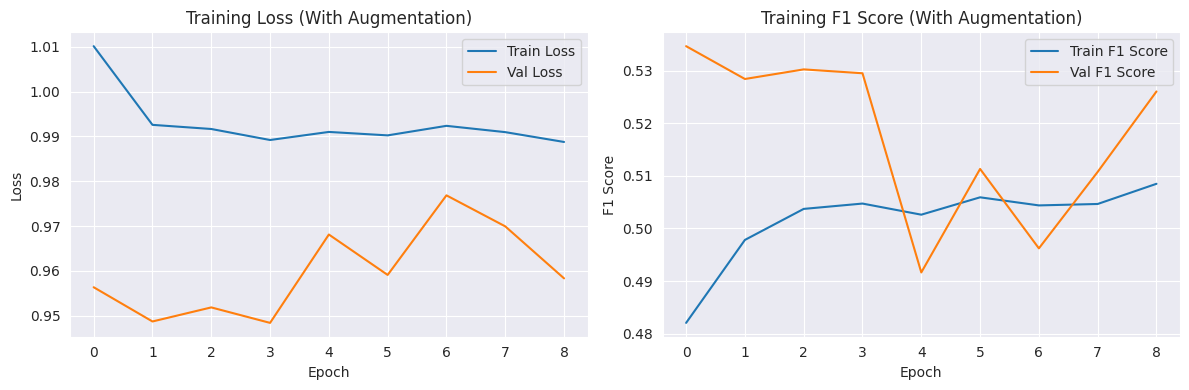

Evaluating on test set...
Final Test F1 Score: 0.5304

2. Training WITHOUT augmentation...
=== TRAINING WITHOUT AUGMENTATION ===
Using GPU: Tesla V100-PCIE-16GB
Loading paths from cache...
Found 16200 image sets
Loading patches from cache...
Extracted 23326 patches before limiting
Original class distribution:
  average: 10976 samples
  rough: 6519 samples
  smooth: 5831 samples

=== LIMITING SAMPLES PER CLASS (MAX: 5000) ===
Original distribution:
  average: 10976 samples
  rough: 6519 samples
  smooth: 5831 samples
  smooth: Limited from 5831 to 5000 samples (removed 831)
  rough: Limited from 6519 to 5000 samples (removed 1519)
  average: Limited from 10976 to 5000 samples (removed 5976)

Final distribution after limiting:
  average: 5000 samples (removed 5976)
  rough: 5000 samples (removed 1519)
  smooth: 5000 samples (removed 831)

Total samples removed: 8326
Total samples remaining: 15000

Dataset split - Train: 9600, Val: 2400, Test: 3000

Final training set distribution:
  aver

Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:15<00:00, 39.48it/s]


Epoch 1/100: Train Loss: 0.9982, F1: 0.4997 | Val Loss: 0.9081, F1: 0.5718 | Loss Diff: -9.0% | LR: 0.001000
New best model saved! Val F1: 0.5718


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:14<00:00, 40.10it/s]


Epoch 2/100: Train Loss: 0.9618, F1: 0.5295 | Val Loss: 0.8982, F1: 0.5786 | Loss Diff: -6.6% | LR: 0.001000
New best model saved! Val F1: 0.5786


...

Epoch 16/100: Train Loss: 0.9478, F1: 0.5565 | Val Loss: 0.8767, F1: 0.5930 | Loss Diff: -7.5% | LR: 0.000700


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:14<00:00, 41.88it/s]


Epoch 17/100: Train Loss: 0.9393, F1: 0.5603 | Val Loss: 0.8866, F1: 0.5929 | Loss Diff: -5.6% | LR: 0.000700


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 600/600 [00:14<00:00, 41.93it/s]


Epoch 18/100: Train Loss: 0.9456, F1: 0.5533 | Val Loss: 0.8892, F1: 0.5865 | Loss Diff: -6.0% | LR: 0.000700
Early stopping due to no improvement in validation F1 for 10 epochs!


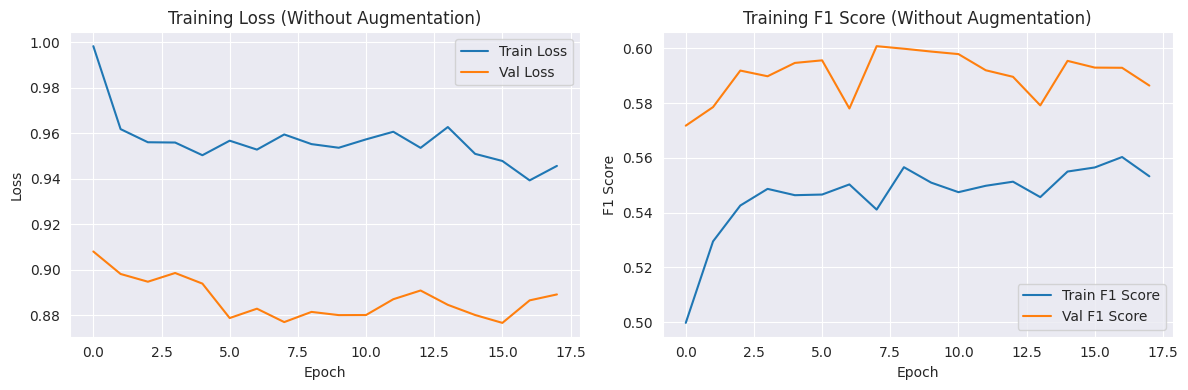


Evaluating on test set...
Final Test F1 Score: 0.5933

3. COMPARISON RESULTS:

📊 PERFORMANCE COMPARISON:
  With Augmentation - Best Val F1: 0.5346
  Without Augmentation - Best Val F1: 0.6009
  Difference: -0.0662
  🏆 Winner: No-augmentation approach performs better

⏱️ TRAINING EFFICIENCY:
  With Augmentation - Epochs: 9
  Without Augmentation - Epochs: 18
  Difference: -9 epochs

📈 DATA USAGE:
  With Augmentation - Balanced classes through duplication
  Without Augmentation - Limited to 5000 samples per class
    smooth: 5000 samples (removed 831)
    rough: 5000 samples (removed 1519)
    average: 5000 samples (removed 5976)


In [20]:
print("=== ROOF TEXTURE CLASSIFICATION - DUAL TRAINING MODE ===")
print("Available training modes:")
print("1. train_with_augmentation() - Aggressive augmentation with class balancing")
print("2. train_without_augmentation() - Limited samples per class, no data duplication")
print("3. compare_training_approaches() - Run both and compare results")
print("4. visualize_augmented_images() - Show augmented vs original images")

# Uncomment to run specific training mode:
# model, history, trainer = train_with_augmentation()
# modelwithoutaug, historywithoutaug, trainerwithoutaug, statswithoutaug = train_without_augmentation()
comparison_results = compare_training_approaches()
